In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
train_data = pd.read_csv(r"D:\Ultimate Programming\Data Bases\Project Dataset\Twitter\twitter_training.csv")
val_data = pd.read_csv(r"D:\Ultimate Programming\Data Bases\Project Dataset\Twitter\twitter_validation.csv")
col = ['Tweet Id', 'Entity','Sentiment','Tweet Content']

train_data.columns = col
val_data.columns = col

## Data Cleaning

In [3]:
train_data.head(3)

,Tweet Id,Entity,Sentiment,Tweet Content
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...


In [4]:
train_data.dropna(inplace=True)

In [5]:
print(train_data.isnull().sum())

Tweet Id         0
Entity           0
Sentiment        0
Tweet Content    0
dtype: int64


In [6]:
print(train_data.duplicated().sum())

2340


In [7]:
train_data.drop_duplicates(inplace=True)

In [8]:
train_data.shape

(71655, 4)

In [9]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 71655 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Tweet Id       71655 non-null  int64 
 1   Entity         71655 non-null  object
 2   Sentiment      71655 non-null  object
 3   Tweet Content  71655 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.7+ MB


## Exploratory Data Analysis

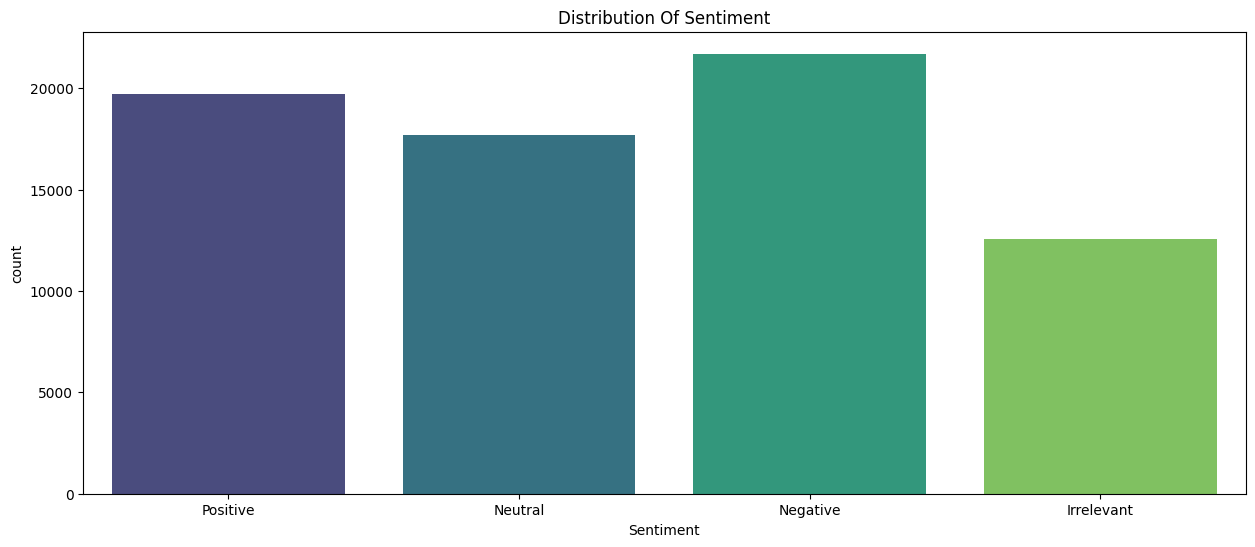

In [10]:
plt.figure(figsize=(15,6))
sns.countplot(data=train_data, x='Sentiment', palette='viridis')
plt.title('Distribution Of Sentiment')
plt.show()

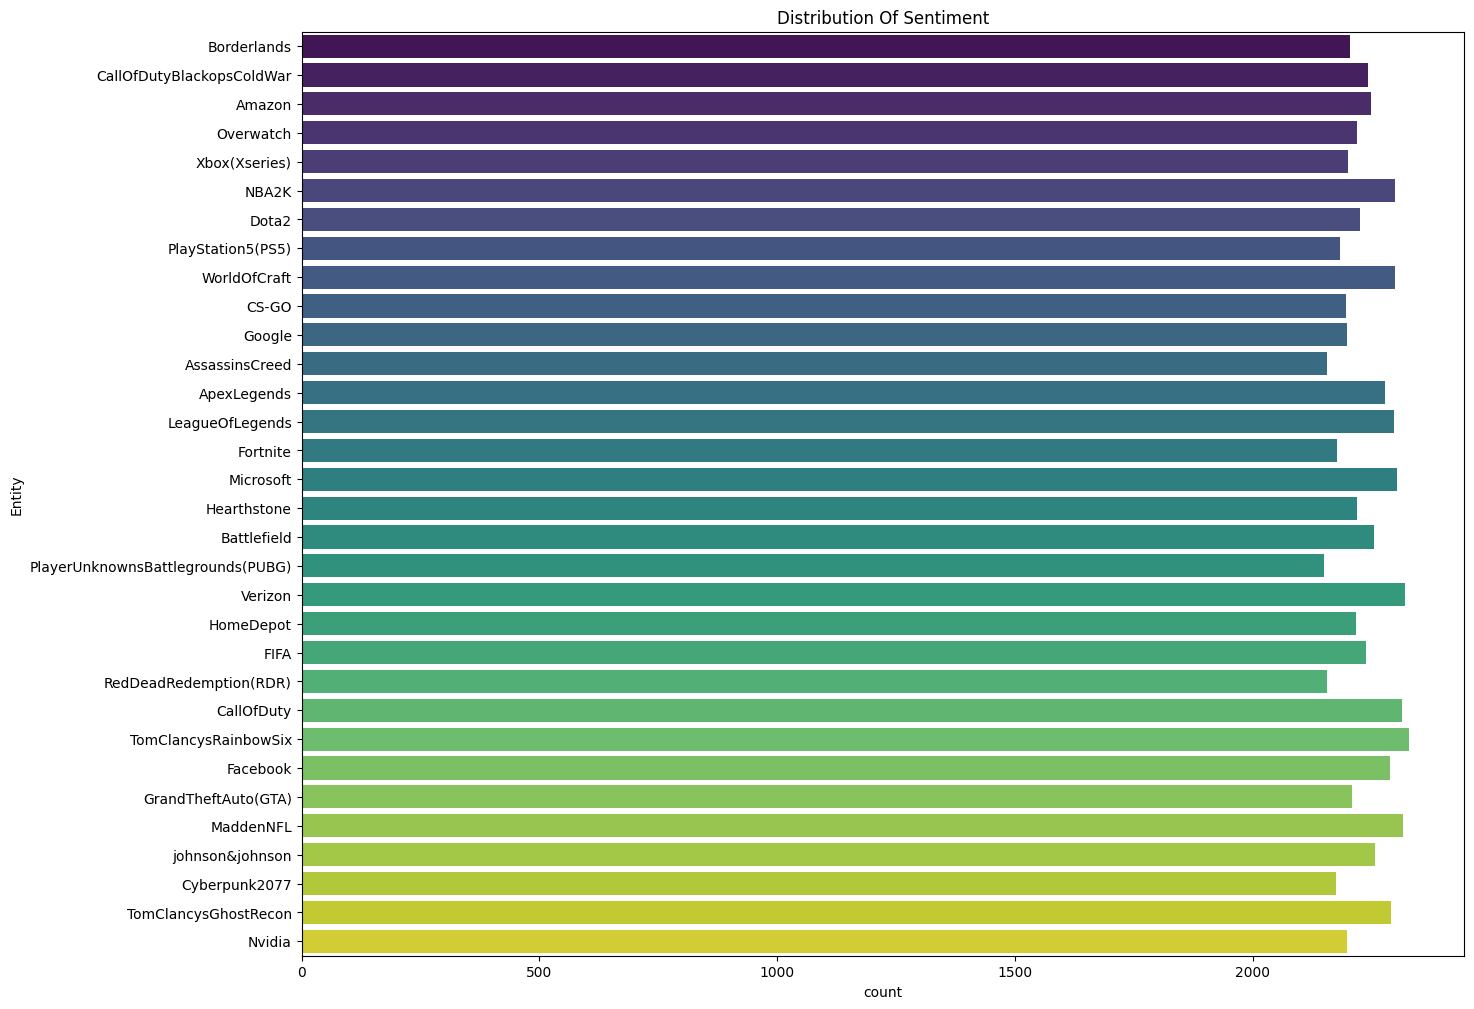

In [11]:
plt.figure(figsize=(15,12))
sns.countplot(data=train_data, y='Entity', palette='viridis')
plt.title('Distribution Of Sentiment')
plt.show()

## Data Preprocessing

In [12]:
train_data['Tweet Content']

0        I am coming to the borders and I will kill you...
1        im getting on borderlands and i will kill you ...
2        im coming on borderlands and i will murder you...
3        im getting on borderlands 2 and i will murder ...
4        im getting into borderlands and i can murder y...
                               ...                        
74676    Just realized that the Windows partition of my...
74677    Just realized that my Mac window partition is ...
74678    Just realized the windows partition of my Mac ...
74679    Just realized between the windows partition of...
74680    Just like the windows partition of my Mac is l...
Name: Tweet Content, Length: 71655, dtype: object

In [13]:
train_data['lower'] = train_data['Tweet Content'].astype(str).str.lower()
train_data['lower'] = train_data['lower'].str.replace('[^A-Za-z0-9 ]+', ' ', regex=True)

In [14]:
train_data.lower.sample(4)

13179                  for this i am grateful and shotchi 
4287       strong sbmm   2 yep  this is going to probab...
48957    black stars dip in both latest fifa official r...
7213     live coverage at tch tv   strackelive  overwat...
Name: lower, dtype: object

In [15]:
data=train_data.groupby(by=["Sentiment"]).count().reset_index()
data.head()

,Sentiment,Tweet Id,Entity,Tweet Content,lower
0,Irrelevant,12537,12537,12537,12537
1,Negative,21698,21698,21698,21698
2,Neutral,17708,17708,17708,17708
3,Positive,19712,19712,19712,19712


In [16]:
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\iamaf\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [17]:
words_token = [word_tokenize(word) for word in train_data['lower']]

In [18]:
print(words_token[0])

['i', 'am', 'coming', 'to', 'the', 'borders', 'and', 'i', 'will', 'kill', 'you', 'all']


In [19]:
from nltk.corpus import stopwords
from string import punctuation

In [20]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\iamaf\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [21]:
stop_words = stopwords.words('english')

In [22]:
from sklearn.feature_extraction.text import CountVectorizer
from nltk.collocations import ngrams

In [23]:
cv1 = CountVectorizer(
    tokenizer=word_tokenize,
    stop_words=stop_words,
    ngram_range=(1, 1)
)

In [24]:
from sklearn.model_selection import train_test_split
reviews_train, reviews_test = train_test_split(train_data, test_size=0.2, random_state=0)

In [26]:
x_train_cv1 = cv1.fit_transform(reviews_train['lower'])
x_test_cv1 = cv1.fit_transform(reviews_train['lower'])

In [27]:
Y_train_cv1 = reviews_train['Sentiment']
y_test_CV1 = reviews_test['Sentiment']

## N-Grams Of 4

In [28]:
cv2 = CountVectorizer(
    tokenizer=word_tokenize,
    stop_words=stop_words,
    ngram_range=(1, 4)
)

In [29]:
x_train_cv2 = cv2.fit_transform(reviews_train['lower'])
x_test_cv2 = cv2.fit_transform(reviews_train['lower'])

In [30]:
Y_train_cv2 = reviews_train['Sentiment']
y_test_CV2 = reviews_test['Sentiment']